In [12]:
import json
import pickle
import random
from tqdm import tqdm
import os
import nlpaug.augmenter.char as nac
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- Константы и пути ---
# Входные файлы
TRAIN_BIO_PATH = "../../data/processed/train_bio.csv"
LIBRARY_PATH = "../../data/processed/components_library.pkl"
COMPONENTS_PATH = "../../data/processed/product_components.jsonl"

# Выходной файл
AUGMENTED_TRAIN_PATH = "../../data/processed/train_augmented_v1.csv"

# --- Загрузка данных ---
print("--- Шаг 1: Загрузка подготовленных данных и артефактов ---")

df_train = pd.read_csv(TRAIN_BIO_PATH, sep=";")
df_train["tokens"] = df_train["tokens"].apply(eval)  # Используем eval, так как ast.literal_eval может быть медленнее
df_train["tags"] = df_train["tags"].apply(eval)
print(f"Загружено {len(df_train)} записей из train_bio.csv")
with open(LIBRARY_PATH, 'rb') as f:
    components_library = pickle.load(f)
print(f"Загружена 'Библиотека Компонентов' с {len(components_library)} категориями.")

# Стало (устойчиво к ошибкам)
# Стало (устойчиво к ошибкам)
product_components = []
print(f"Информация: Чтение 'сломанного' файла {COMPONENTS_PATH}...")
try:
    with open(COMPONENTS_PATH, 'r', encoding='utf-8') as f:
        # Читаем ВЕСЬ файл как одну гигантскую строку
        full_file_content = f.read()

    # Теперь мы РАЗРЕЗАЕМ эту строку по нашему "фантомному" разделителю '\\n'
    json_strings = full_file_content.split('\\n')

    print(f"Найдено {len(json_strings)} потенциальных JSON-объектов.")

    for i, s in enumerate(json_strings):
        # Убираем лишние пробелы по краям
        clean_s = s.strip()

        # Пропускаем пустые строки, которые могли образоваться после split
        if not clean_s:
            continue

        try:
            # Пытаемся распарсить каждый кусочек
            product_components.append(json.loads(clean_s))
        except json.JSONDecodeError as e:
            # Если какой-то кусочек "битый", сообщим об этом
            print(f"Предупреждение: Не удалось распарсить фрагмент №{i + 1}. Ошибка: {e}.")
            print(f" > Содержимое фрагмента: {clean_s[:100]}...")

except FileNotFoundError as e:
    print(f"Ошибка: Не найден файл компонентов. {e}")

--- Шаг 1: Загрузка подготовленных данных и артефактов ---
Загружено 23163 записей из train_bio.csv
Загружена 'Библиотека Компонентов' с 149 категориями.
Информация: Чтение 'сломанного' файла ../../data/processed/product_components.jsonl...
Найдено 13755 потенциальных JSON-объектов.


In [13]:
print("--- Шаг 2: Создание функций-аугментаторов ---")

# 1. Аугментатор Регистра
def augment_case(text: str) -> str:
    r = random.random()
    if r < 0.4: return text.lower()
    if r < 0.7: return text.title()
    if r < 0.9: return text.upper()
    return text

# 2. Аугментатор Опечаток
typo_augmenter = nac.KeyboardAug(aug_char_p=0.05, aug_word_p=0.1)

# План Б, если предыдущий вариант не сработал
def augment_typos(text: str) -> str:
    result = typo_augmenter.augment(text)
    # Проверяем, что на выходе - строка. nlpaug иногда возвращает список.
    if isinstance(result, list):
        return result[0]
    return result

# 3. Аугментатор Перестановок
def augment_permutation(entities: list) -> list:
    permuted = entities[:]
    random.shuffle(permuted)
    return permuted

# 4. Семантический Аугментатор (пока простой)
def augment_semantic(entity_text: str, entity_label: str, library: dict) -> str:
    # Для этого примера мы будем заменять только TYPE на другой случайный TYPE
    if entity_label == "TYPE":
        all_types = list(library.keys())
        # Убираем 'all_brands'
        if 'all_brands' in all_types: all_types.remove('all_brands')

        if len(all_types) > 1:
            # Выбираем новый тип, который не совпадает со старым
            new_type = random.choice(all_types)
            while new_type.lower() == entity_text.lower():
                new_type = random.choice(all_types)
            return new_type

    return entity_text

print("Функции-аугментаторы успешно определены.")

--- Шаг 2: Создание функций-аугментаторов ---
Функции-аугментаторы успешно определены.


In [14]:
print("\n--- Шаг 3: Запуск Конвейера А ('Закалка Реальности') ---")

augmented_from_train = []
REPLICATION_FACTOR = 5

for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Аугментация train.csv"):
    tokens, tags = row['tokens'], row['tags']

    for _ in range(REPLICATION_FACTOR):
        new_tokens, new_tags = [], []

        # Сначала сгруппируем сущности
        entities = []
        i = 0
        while i < len(tokens):
            if tags[i].startswith("B-"):
                label = tags[i][2:]
                entity_tokens = [tokens[i]]
                j = i + 1
                while j < len(tags) and tags[j] == f"I-{label}":
                    entity_tokens.append(tokens[j])
                    j += 1
                entities.append((" ".join(entity_tokens), label))
                i = j
            else:
                entities.append((tokens[i], 'O'))
                i += 1

        # Аугментируем и собираем обратно
        for text, label in entities:
            if label != 'O' and random.random() < 0.5: # 50% шанс аугментировать сущность
                augmented_text = augment_case(text)
                if random.random() < 0.3: # 30% шанс добавить опечатку
                    augmented_text = augment_typos(augmented_text)
            else:
                augmented_text = text

            # Разделяем обратно на токены и генерируем теги
            current_tokens = augmented_text.split()
            new_tokens.extend(current_tokens)
            if label != 'O':
                new_tags.append(f"B-{label}")
                new_tags.extend([f"I-{label}"] * (len(current_tokens) - 1))
            else:
                new_tags.extend(['O'] * len(current_tokens))

        augmented_from_train.append({'tokens': new_tokens, 'tags': new_tags})

print(f"Сгенерировано {len(augmented_from_train)} новых примеров на основе train.csv.")


--- Шаг 3: Запуск Конвейера А ('Закалка Реальности') ---


Аугментация train.csv: 100%|██████████| 23163/23163 [00:02<00:00, 7755.70it/s] 

Сгенерировано 115815 новых примеров на основе train.csv.


In [15]:
print("\n--- Шаг 4: Запуск Конвейера Б ('Фабрика Синтетики') ---")

synthetic_data = []
NUM_SYNTHETIC_SAMPLES = 25000

templates = [
    ["TYPE", "BRAND"],
    ["TYPE", "BRAND", "VOLUME"],
    ["BRAND", "TYPE", "VOLUME", "PERCENT"],
    ["TYPE", "PERCENT"],
    ["VOLUME", "TYPE"],
]

for _ in tqdm(range(NUM_SYNTHETIC_SAMPLES), desc="Генерация синтетики"):
    source_product = random.choice(product_components)
    entities = source_product['entities']

    available_labels = list(entities.keys())
    possible_templates = [t for t in templates if all(label in available_labels for label in t)]

    if not possible_templates: continue
    chosen_template = random.choice(possible_templates)

    query_entities = []
    for label in chosen_template:
        entity_text = random.choice(entities[label])

        # Применяем аугментации к компонентам
        if random.random() < 0.6: # 60% шанс на аугментацию компонента
             entity_text = augment_case(augment_typos(entity_text))

        query_entities.append((entity_text, label))

    # Применяем перестановку
    if len(query_entities) > 1:
        query_entities = augment_permutation(query_entities)

    final_tokens, final_tags = [], []
    for text, label in query_entities:
        tokens = text.split()
        if not tokens: continue
        final_tokens.extend(tokens)
        final_tags.append(f"B-{label}")
        final_tags.extend([f"I-{label}"] * (len(tokens) - 1))

    if final_tokens:
        synthetic_data.append({'tokens': final_tokens, 'tags': final_tags})

print(f"Сгенерировано {len(synthetic_data)} синтетических примеров.")


--- Шаг 4: Запуск Конвейера Б ('Фабрика Синтетики') ---


Генерация синтетики: 100%|██████████| 25000/25000 [00:00<00:00, 61320.09it/s]

Сгенерировано 10368 синтетических примеров.


In [16]:
print("\n--- Шаг 5: Финальная сборка и сохранение датасета ---")

df_original = df_train[['tokens', 'tags']]
df_augmented_train = pd.DataFrame(augmented_from_train)
df_synthetic = pd.DataFrame(synthetic_data)

final_df = pd.concat([df_original, df_augmented_train, df_synthetic], ignore_index=True)

# Убираем пустые примеры, которые могли случайно сгенерироваться
final_df = final_df[final_df['tokens'].apply(len) > 0]
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

final_df.to_csv(AUGMENTED_TRAIN_PATH, sep=";", index=False)

print(f"Финальный аугментированный датасет создан.")
print(f"  - Исходных примеров: {len(df_original)}")
print(f"  - Примеров из 'Конвейера А': {len(df_augmented_train)}")
print(f"  - Синтетических примеров ('Конвейер Б'): {len(df_synthetic)}")
print(f"  - Итоговый размер: {len(final_df)} примеров.")
print(f"Датасет сохранен в: {AUGMENTED_TRAIN_PATH}")


--- Шаг 5: Финальная сборка и сохранение датасета ---
Финальный аугментированный датасет создан.
  - Исходных примеров: 23163
  - Примеров из 'Конвейера А': 115815
  - Синтетических примеров ('Конвейер Б'): 10368
  - Итоговый размер: 149346 примеров.
Датасет сохранен в: ../../data/processed/train_augmented_v1.csv


In [17]:
final_df.sample(10, random_state=42)

,tokens,tags
98259,"[▁montar, ell]","[B-BRAND, I-BRAND]"
59848,"[▁ле, щ]","[B-TYPE, I-TYPE]"
13861,"[▁, оли, вки, ▁боя, ри]","[B-TYPE, I-TYPE, I-TYPE, B-BRAND, I-BRAND]"
18040,"[▁, кол, баса, ▁в, ▁на, ре]","[B-TYPE, I-TYPE, I-TYPE, O, O, O]"
95508,"[▁мор, з]","[O, O]"
107786,"[▁кор, ови, но, ▁В, АРЕН, Н]","[B-BRAND, I-BRAND, I-BRAND, B-TYPE, I-TYPE, I-..."
94003,"[▁, vresk, o]","[B-BRAND, I-BRAND, I-BRAND]"
54066,"[▁на, г, ге, сты]","[B-TYPE, I-TYPE, I-TYPE, I-TYPE]"
35345,"[▁, Поро, Шок, ▁для, ▁роз, ового]","[B-TYPE, I-TYPE, I-TYPE, O, O, O]"
99312,"[▁, шоколад, ▁о, соб, ый]","[B-TYPE, I-TYPE, B-TYPE, I-TYPE, I-TYPE]"



--- Шаг 6: Финальный анализ распределения сущностей ---
Сравнение количества сущностей (B-тегов):
dataset  Аугментированный  Исходный
entity                             
BRAND               43872      6556
PERCENT              1099        29
TYPE               158496     24688
VOLUME               8055        67

График сравнения сохранен в: ../../reports/figures/augmentation_impact_v1.png


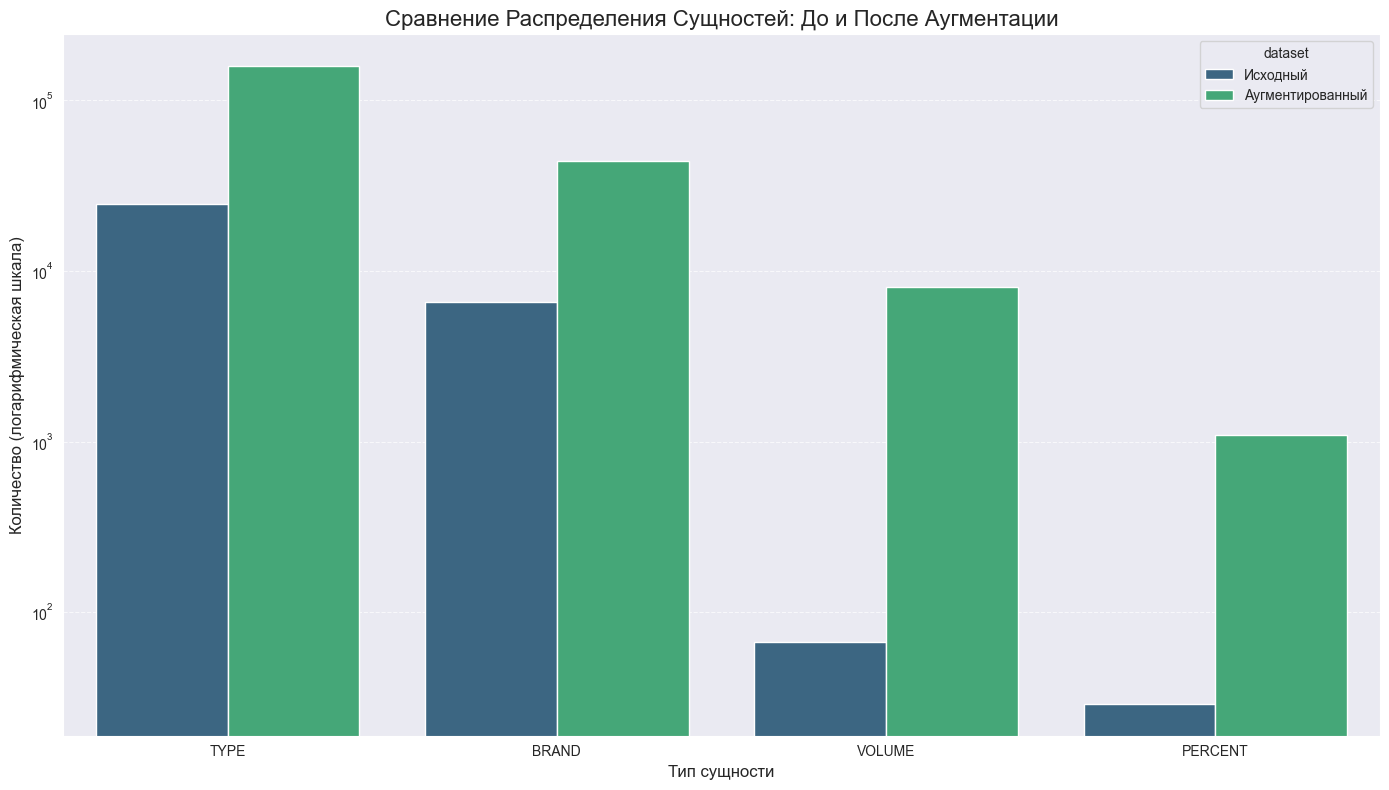

In [18]:
print("\n--- Шаг 6: Финальный анализ распределения сущностей ---")

def count_entities(df, name=""):
    counts = Counter()
    for tags_list in df['tags']:
        for tag in tags_list:
            if tag.startswith("B-"):
                counts[tag[2:]] += 1

    df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).reset_index()
    df_counts = df_counts.rename(columns={'index': 'entity'})
    df_counts['dataset'] = name
    return df_counts

original_counts_df = count_entities(df_original, name="Исходный")
final_counts_df = count_entities(final_df, name="Аугментированный")

comparison_df = pd.concat([original_counts_df, final_counts_df])

print("Сравнение количества сущностей (B-тегов):")
print(comparison_df.pivot(index='entity', columns='dataset', values='count').fillna(0).astype(int))

plt.figure(figsize=(14, 8))
sns.barplot(data=comparison_df, x='entity', y='count', hue='dataset', palette='viridis')
plt.title('Сравнение Распределения Сущностей: До и После Аугментации', fontsize=16)
plt.xlabel('Тип сущности', fontsize=12)
plt.ylabel('Количество (логарифмическая шкала)', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

output_chart_path = "../../reports/figures/augmentation_impact_v1.png"
os.makedirs(os.path.dirname(output_chart_path), exist_ok=True)
plt.savefig(output_chart_path)
print(f"\nГрафик сравнения сохранен в: {output_chart_path}")

plt.show()